# Decision Tree classifier

#### Import required modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Load sample dataset

In [2]:
df = pd.read_csv('Breast cancer dataset/Breast_cancer_data.csv')

### inspect dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [4]:
df.sample(n=6)

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
429,12.72,17.67,80.98,501.3,0.07896,1
386,12.21,14.09,78.78,462.0,0.08108,1
244,19.40,23.50,129.10,1155.0,0.10270,0
13,15.85,23.95,103.70,782.7,0.08401,0
410,11.36,17.57,72.49,399.8,0.08858,1
31,11.84,18.70,77.93,440.6,0.11090,0


In [5]:
df.sample(n=10)

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
202,23.290,26.67,158.90,1685.0,0.11410,0
510,11.740,14.69,76.31,426.0,0.08099,1
186,18.310,18.58,118.60,1041.0,0.08588,0
157,16.840,19.46,108.40,880.2,0.07445,1
66,9.465,21.01,60.11,269.4,0.10440,1
15,14.540,27.54,96.73,658.8,0.11390,0
151,8.219,20.70,53.27,203.9,0.09405,1
329,16.260,21.88,107.50,826.8,0.11650,0
65,14.780,23.94,97.40,668.3,0.11720,0
504,9.268,12.87,61.49,248.7,0.16340,1


### Dataset Features description

In this dataset, row labelled as 0 indicates Malignant (Cancerous). While row labelled as 1 indicates Benign (non-cancerous).

For Malignant:
  1. mean_radius --> HIGH
  2. mean_texture --> HIGH variations
  3. mean_parimeter --> HIGH
  4. mean_area --> HIGH

For Benign:
  1. mean_radius --> LOW
  2. mean_texture --> smooth variations
  3. mean_parimeter --> LOW
  4. mean_area --> LOW


In [6]:
# 
df.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [7]:
# identify duplicate rows
df.duplicated().sum()

0

In [8]:
# Find correlation between numerical features
df.corr()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
mean_radius,1.000000,0.323782,0.997855,0.987357,0.170581,-0.730029
mean_texture,0.323782,1.000000,0.329533,0.321086,-0.023389,-0.415185
mean_perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,-0.742636
mean_area,0.987357,0.321086,0.986507,1.000000,0.177028,-0.708984
mean_smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,-0.358560
diagnosis,-0.730029,-0.415185,-0.742636,-0.708984,-0.358560,1.000000


<Axes: >

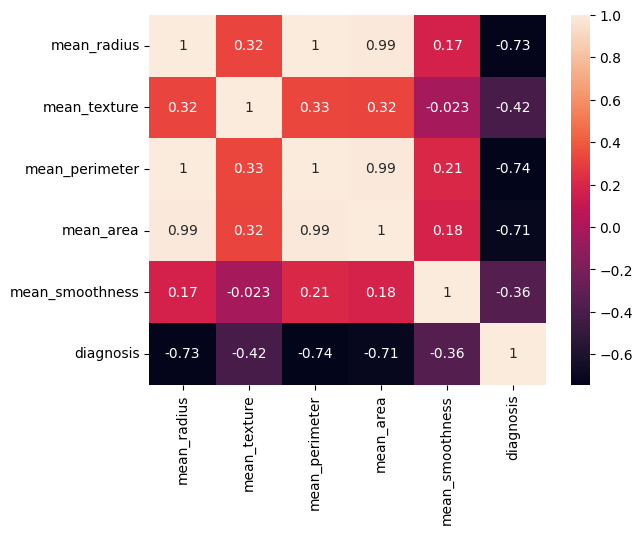

In [9]:
# plotting Correlation heatmap

sns.heatmap(df.corr(), annot=True)

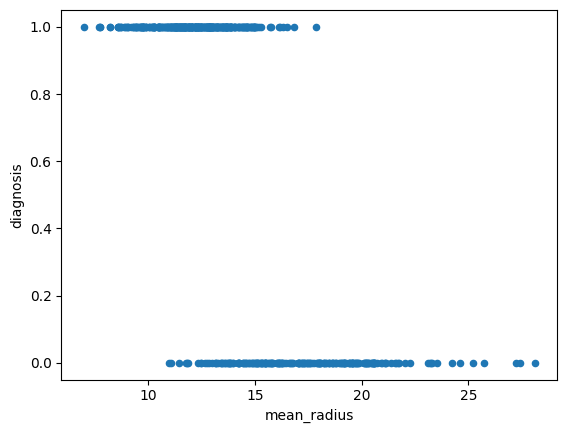

In [10]:
df.plot(x='mean_radius', y='diagnosis', kind='scatter')

plt.show()

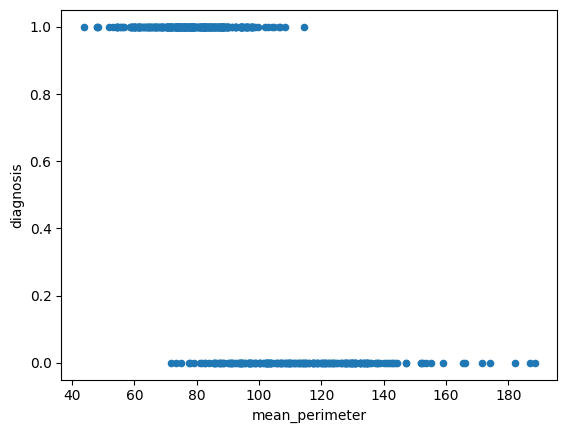

In [11]:
df.plot(x='mean_perimeter', y='diagnosis', kind='scatter')
plt.show()

### Decision Tree using SKLearn

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

#### seperating features for X and Y

In [13]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [14]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [15]:
X_train

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness
559,11.51,23.93,74.52,403.5,0.09261
295,13.77,13.27,88.06,582.7,0.09198
264,17.19,22.07,111.60,928.3,0.09726
125,13.85,17.21,88.44,588.7,0.08785
280,19.16,26.60,126.20,1138.0,0.10200
...,...,...,...,...,...
98,11.60,12.84,74.34,412.6,0.08983
322,12.86,13.32,82.82,504.8,0.11340
382,12.05,22.72,78.75,447.8,0.06935
365,20.44,21.78,133.80,1293.0,0.09150


In [ ]:
d_tree = DecisionTreeClassifier(max_depth=6)

In [17]:
d_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6)

Since I am using Classification model, so the evaluation metric will be accuracy

In [18]:
# Evaluating model performance on train data
print("Accuracy: ", d_tree.score(X_train, y_train))

Accuracy:  0.9874371859296482


In [19]:
print('Accuracy: ', d_tree.score(X_test, y_test))

Accuracy:  0.9005847953216374


In [20]:
X_test.iloc[0:5]

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness
333,11.250,14.78,71.38,390.0,0.08306
273,9.742,15.67,61.50,289.9,0.09037
201,17.540,19.32,115.10,951.6,0.08968
178,13.010,22.22,82.01,526.4,0.06251
85,18.460,18.52,121.10,1075.0,0.09874


In [21]:
y_train.iloc[0:5]

559    1
295    1
264    0
125    1
280    0
Name: diagnosis, dtype: int64

In [22]:
X.columns

Index(['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
       'mean_smoothness'],
      dtype='object')

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
y_pred = d_tree.predict(X_test)

In [26]:
conf_mat = confusion_matrix(y_test, y_pred)

conf_mat

array([[56, 12],
       [ 5, 98]], dtype=int64)

<Axes: >

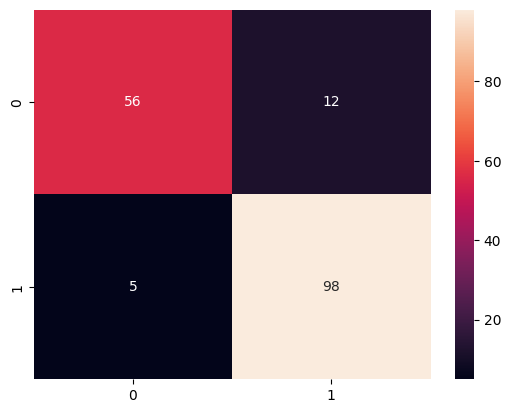

In [27]:
sns.heatmap(conf_mat, annot=True)

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87        68
           1       0.89      0.95      0.92       103

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



Exporting DecisionTree plot and visualizing later using Graphviz 

In [29]:
from sklearn.tree import export_graphviz

In [30]:
export_graphviz(d_tree, out_file="tree.dot", class_names=["malignant", "benign"],
feature_names=X.columns, filled=True)

In [31]:
import graphviz

In [32]:
with open('tree.dot') as f:
    d_tree_graph = f.read()


In [33]:
d_tree_graph

'digraph Tree {\nnode [shape=box, style="filled", color="black", fontname="helvetica"] ;\nedge [fontname="helvetica"] ;\n0 [label="mean_area <= 696.25\\ngini = 0.462\\nsamples = 398\\nvalue = [144, 254]\\nclass = benign", fillcolor="#a9d5f4"] ;\n1 [label="mean_perimeter <= 87.48\\ngini = 0.199\\nsamples = 277\\nvalue = [31, 246]\\nclass = benign", fillcolor="#52a9e8"] ;\n0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;\n2 [label="mean_smoothness <= 0.109\\ngini = 0.085\\nsamples = 202\\nvalue = [9, 193]\\nclass = benign", fillcolor="#42a2e6"] ;\n1 -> 2 ;\n3 [label="mean_texture <= 21.575\\ngini = 0.043\\nsamples = 181\\nvalue = [4, 177]\\nclass = benign", fillcolor="#3d9fe6"] ;\n2 -> 3 ;\n4 [label="gini = 0.0\\nsamples = 145\\nvalue = [0, 145]\\nclass = benign", fillcolor="#399de5"] ;\n3 -> 4 ;\n5 [label="mean_texture <= 21.59\\ngini = 0.198\\nsamples = 36\\nvalue = [4, 32]\\nclass = benign", fillcolor="#52a9e8"] ;\n3 -> 5 ;\n6 [label="gini = 0.0\\nsamples = 1\\nvalue = [1

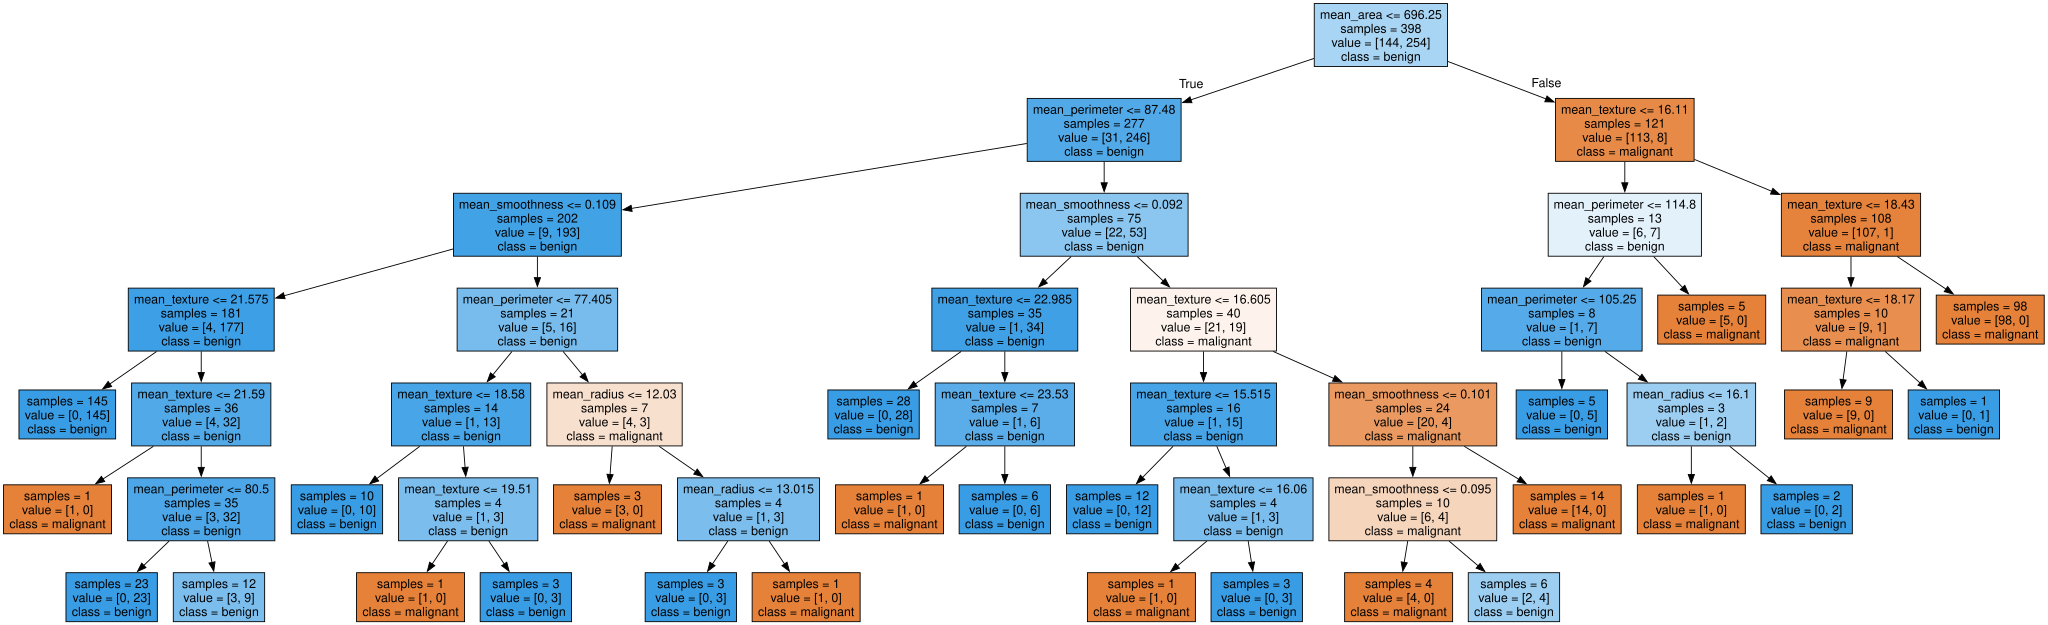

In [69]:
graphviz.Source(d_tree_graph)

Get the importance of Features helping in prredicting the output

In [34]:
print('Feature importance: ', d_tree.feature_importances_)

Feature importance:  [0.01091856 0.17004117 0.1021931  0.64425055 0.07259662]


mean_radius	      --> 0.0269  
mean_texture	  --> 0.1603  
mean_perimeter	  --> 0.0782  
mean_area	      --> 0.6498  
mean_smoothness   --> 0.0846  

In [35]:
import numpy as np

In [36]:
columns_ = np.array(X.columns)

columns_

array(['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
       'mean_smoothness'], dtype=object)

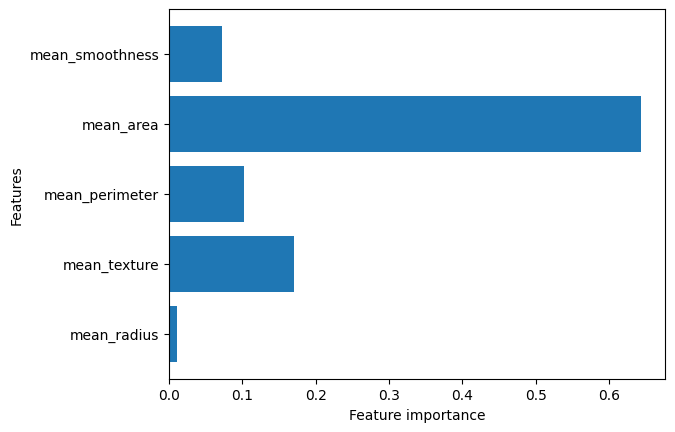

In [37]:
plt.barh(columns_, d_tree.feature_importances_, align='center')
plt.xlabel('Feature importance')
plt.ylabel('Features')

plt.show()